# Discussion 4: Greyscale Sickle Cell Detection

This notebook converts the blood-smear image to greyscale, builds a binary cell mask, uses a shape-aware distance-transform watershed to separate touching erythrocytes, and then flags sickle-cell candidates from shape measurements.

The detection is based on morphology only. It uses each cell's major-axis length, minor-axis length, aspect ratio, eccentricity, solidity, and axis difference so elongated or curved abnormal cells are caught more reliably than with aspect ratio alone while avoiding extra watershed splits inside single oblong cells.

This is an educational image-processing workflow, not a clinical diagnostic tool.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches
from PIL import Image
from scipy import ndimage as ndi
from skimage import color, feature, filters, measure, morphology, segmentation

plt.rcParams["figure.figsize"] = (10, 7)
plt.rcParams["axes.titlesize"] = 14

image_path = Path("Blood-smear-of-a-patient-with-Sickle-Cell-Disease.webp")
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

overlay_path = output_dir / "sickle_cell_candidates.png"
table_path = output_dir / "erythrocyte_measurements.csv"

image_rgb = np.array(Image.open(image_path).convert("RGB"))
image_gray = color.rgb2gray(image_rgb)

print(f"Image: {image_path}")
print(f"Shape: {image_rgb.shape}")
print(f"Overlay output: {overlay_path}")
print(f"Table output: {table_path}")

Image: Blood-smear-of-a-patient-with-Sickle-Cell-Disease.webp
Shape: (301, 450, 3)
Overlay output: outputs\sickle_cell_candidates.png
Table output: outputs\erythrocyte_measurements.csv


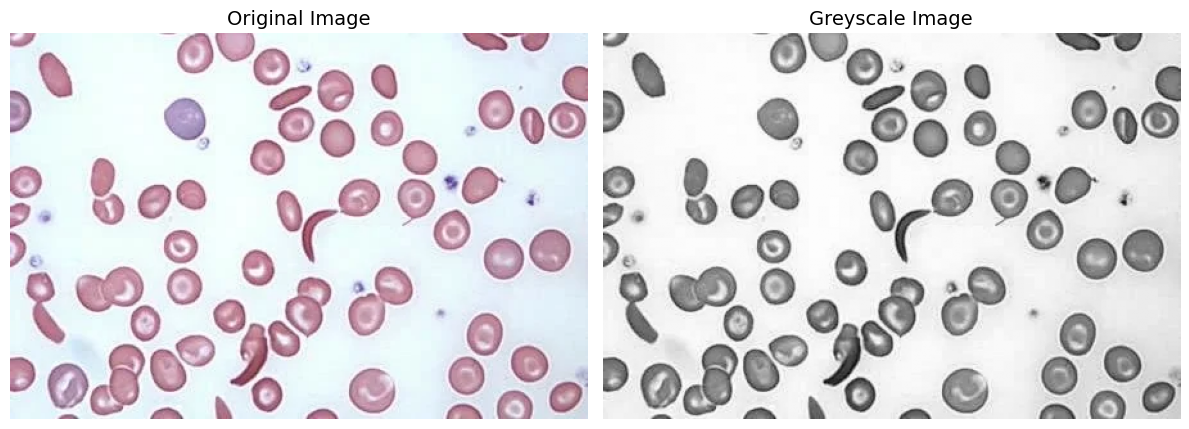

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(image_gray, cmap="gray")
axes[1].set_title("Greyscale Image")
axes[1].axis("off")

plt.tight_layout()

In [3]:
# Build a binary mask from the greyscale image.
smoothed = filters.gaussian(image_gray, sigma=1.0)
otsu_threshold = filters.threshold_otsu(smoothed)
cell_mask = smoothed < otsu_threshold
cell_mask = morphology.remove_small_objects(cell_mask, min_size=80)
cell_mask = morphology.remove_small_holes(cell_mask, area_threshold=80)

# Estimate a typical single-cell area from connected components so elongated but still
# single erythrocytes are less likely to receive multiple watershed seeds.
component_labels = measure.label(cell_mask)
single_cell_components = [
    region.area
    for region in measure.regionprops(component_labels)
    if 120 <= region.area <= 1200
]
single_cell_area = float(np.median(single_cell_components)) if single_cell_components else 600.0

# Smooth the distance map, detect peaks, then cap the number of markers in each connected
# component so circular and oblong single cells are not over-split by watershed.
distance_map = ndi.distance_transform_edt(cell_mask)
distance_smooth = filters.gaussian(distance_map, sigma=1.2)
peak_coords = feature.peak_local_max(
    distance_smooth,
    labels=cell_mask,
    min_distance=12,
    threshold_rel=0.25,
    exclude_border=False,
)

marker_mask = np.zeros_like(cell_mask, dtype=bool)
for region in measure.regionprops(component_labels):
    if region.area < 120:
        continue

    component_peak_coords = peak_coords[
        component_labels[peak_coords[:, 0], peak_coords[:, 1]] == region.label
    ] if len(peak_coords) else np.empty((0, 2), dtype=int)
    aspect_ratio = region.major_axis_length / max(region.minor_axis_length, 1e-6)
    expected_markers = max(1, int(np.ceil(region.area / (single_cell_area * 1.35))))

    if region.area < single_cell_area * 1.6 and aspect_ratio <= 3.4:
        expected_markers = 1

    if len(component_peak_coords) == 0:
        component_pixels = np.argwhere(component_labels == region.label)
        component_values = distance_smooth[component_labels == region.label]
        marker_mask[tuple(component_pixels[np.argmax(component_values)])] = True
        continue

    peak_values = distance_smooth[component_peak_coords[:, 0], component_peak_coords[:, 1]]
    keep_indices = np.argsort(peak_values)[-expected_markers:]
    marker_mask[tuple(component_peak_coords[keep_indices].T)] = True

markers, _ = ndi.label(marker_mask)
labeled_cells = segmentation.watershed(-distance_smooth, markers, mask=cell_mask)

print(f"Otsu threshold: {otsu_threshold:.4f}")
print(f"Estimated single-cell area: {single_cell_area:.1f} pixels")
print(f"Watershed markers used: {markers.max()}")
print(f"Detected watershed regions: {labeled_cells.max()}")

Otsu threshold: 0.7754
Estimated single-cell area: 594.5 pixels
Watershed markers used: 63
Detected watershed regions: 63


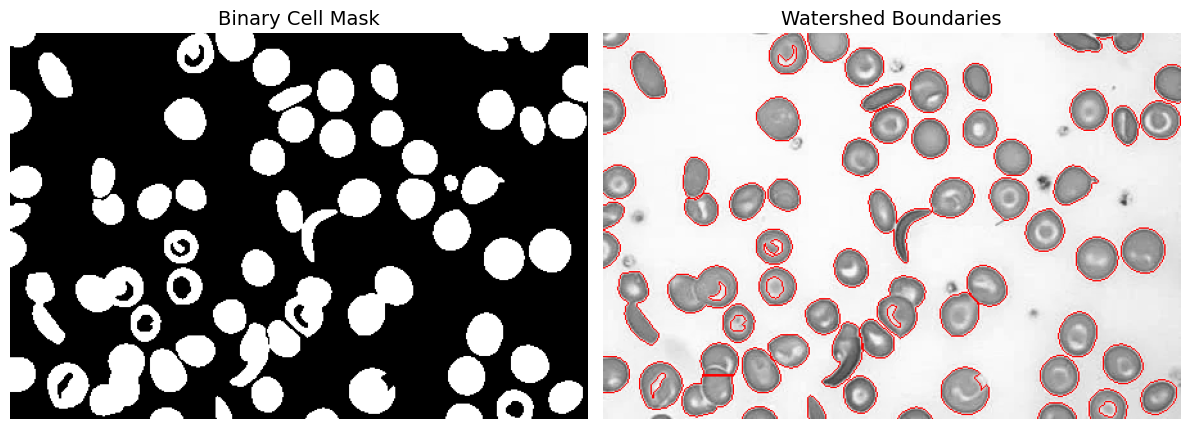

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cell_mask, cmap="gray")
axes[0].set_title("Binary Cell Mask")
axes[0].axis("off")

axes[1].imshow(segmentation.mark_boundaries(image_gray, labeled_cells, color=(1, 0, 0)))
axes[1].set_title("Watershed Boundaries")
axes[1].axis("off")

plt.tight_layout()

In [5]:
records = []

for region in measure.regionprops(labeled_cells):
    if region.area < 120 or region.area > 4000:
        continue
    if region.minor_axis_length < 8:
        continue

    min_row, min_col, max_row, max_col = region.bbox
    major_axis = float(region.major_axis_length)
    minor_axis = float(region.minor_axis_length)
    aspect_ratio = major_axis / max(minor_axis, 1e-6)
    axis_difference = major_axis - minor_axis
    eccentricity = float(region.eccentricity)
    solidity = float(region.solidity)
    touches_border = (
        min_row == 0
        or min_col == 0
        or max_row == labeled_cells.shape[0]
        or max_col == labeled_cells.shape[1]
    )

    likely_split_fragment = (
        region.area < single_cell_area * 0.45
        and aspect_ratio >= 2.2
        and solidity >= 0.93
    )
    sickle_candidate = (not likely_split_fragment) and (
        (aspect_ratio >= 2.2 and region.area >= single_cell_area * 0.45)
        or (aspect_ratio >= 1.9 and eccentricity >= 0.84 and axis_difference >= 14 and region.area >= single_cell_area * 0.45)
        or (aspect_ratio >= 1.7 and eccentricity >= 0.88 and solidity <= 0.90 and axis_difference >= 12 and region.area >= single_cell_area * 0.50)
    )

    records.append(
        {
            "label": int(region.label),
            "area": float(region.area),
            "centroid_row": float(region.centroid[0]),
            "centroid_col": float(region.centroid[1]),
            "major_axis_length": major_axis,
            "minor_axis_length": minor_axis,
            "axis_difference": axis_difference,
            "aspect_ratio": aspect_ratio,
            "eccentricity": eccentricity,
            "solidity": solidity,
            "touches_border": bool(touches_border),
            "sickle_candidate": bool(sickle_candidate),
            "min_row": int(min_row),
            "min_col": int(min_col),
            "max_row": int(max_row),
            "max_col": int(max_col),
        }
    )

features = pd.DataFrame(records).sort_values(["sickle_candidate", "aspect_ratio"], ascending=[False, False]).reset_index(drop=True)

print(f"Usable erythrocytes measured: {len(features)}")
print(f"Sickle-cell candidates: {int(features['sickle_candidate'].sum())}")
print(f"Candidates touching image border: {int((features['sickle_candidate'] & features['touches_border']).sum())}")

features.head(12)

Usable erythrocytes measured: 63
Sickle-cell candidates: 5
Candidates touching image border: 2


,label,area,centroid_row,centroid_col,major_axis_length,minor_axis_length,axis_difference,aspect_ratio,eccentricity,solidity,touches_border,sickle_candidate,min_row,min_col,max_row,max_col
0,3,766.0,5.930809,386.432115,76.223616,16.517515,59.706101,4.614714,0.976239,0.822771,True,True,0,352,16,420
1,39,867.0,212.470588,25.808535,65.878317,21.322821,44.555496,3.089569,0.946170,0.771352,False,True,187,12,243,43
2,10,399.0,50.508772,217.340852,37.404757,13.680071,23.724686,2.734252,0.930721,0.945498,False,True,41,201,62,235
3,47,829.0,250.322075,188.484922,53.522772,22.510028,31.012745,2.377730,0.907260,0.829830,False,True,226,171,276,202
4,62,276.0,295.300725,352.844203,28.704327,12.964619,15.739708,2.214051,0.892190,0.971831,True,True,289,339,301,368
5,61,159.0,297.025157,242.716981,24.687330,8.834538,15.852791,2.794411,0.933776,0.940828,True,False,292,230,301,256
6,59,179.0,296.715084,121.351955,25.507821,9.502301,16.005520,2.684383,0.928022,0.962366,True,False,292,109,301,135
7,33,267.0,168.250936,4.850187,26.871745,13.603935,13.267810,1.975292,0.862384,0.970909,True,False,155,0,183,13
8,12,454.0,61.167401,6.715859,34.006210,17.967312,16.038899,1.892671,0.849024,0.978448,True,False,45,0,79,17
9,6,648.0,33.608025,34.680556,39.577264,20.912363,18.664901,1.892530,0.849000,0.964286,False,False,16,22,51,49


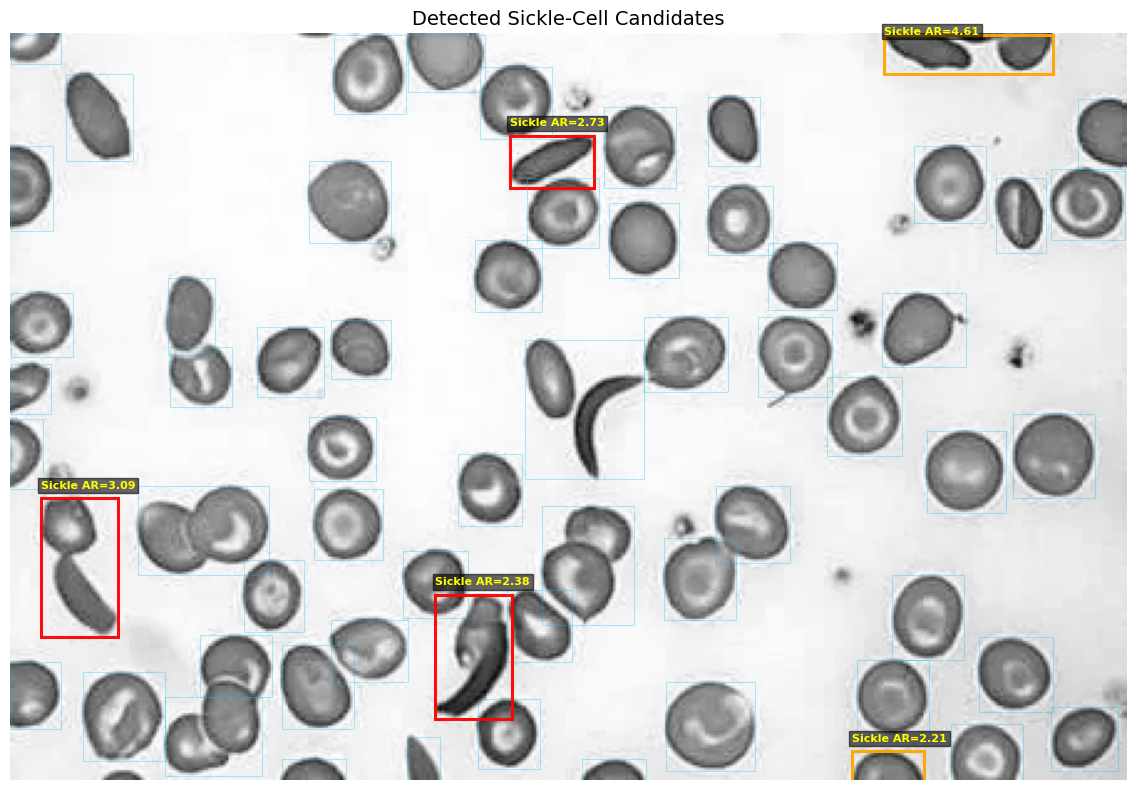

Saved overlay image to: outputs\sickle_cell_candidates.png
Saved measurements table to: outputs\erythrocyte_measurements.csv


In [6]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(image_gray, cmap="gray")
ax.set_title("Detected Sickle-Cell Candidates")
ax.axis("off")

for row in features.itertuples(index=False):
    width = row.max_col - row.min_col
    height = row.max_row - row.min_row

    if row.sickle_candidate:
        edgecolor = "red" if not row.touches_border else "orange"
        linewidth = 2.2
        alpha = 0.95
        label = f"Sickle AR={row.aspect_ratio:.2f}"
    else:
        edgecolor = "deepskyblue"
        linewidth = 0.8
        alpha = 0.30
        label = None

    rect = patches.Rectangle(
        (row.min_col, row.min_row),
        width,
        height,
        linewidth=linewidth,
        edgecolor=edgecolor,
        facecolor="none",
        alpha=alpha,
    )
    ax.add_patch(rect)

    if label is not None:
        ax.text(
            row.min_col,
            max(row.min_row - 4, 0),
            label,
            color="yellow",
            fontsize=8,
            weight="bold",
            bbox={"facecolor": "black", "alpha": 0.60, "pad": 2},
        )

plt.tight_layout()
fig.savefig(overlay_path, dpi=200, bbox_inches="tight")
plt.show()

features.to_csv(table_path, index=False)
print(f"Saved overlay image to: {overlay_path}")
print(f"Saved measurements table to: {table_path}")

In [7]:
summary = features.loc[
    :, [
        "label",
        "major_axis_length",
        "minor_axis_length",
        "axis_difference",
        "aspect_ratio",
        "eccentricity",
        "solidity",
        "touches_border",
        "sickle_candidate",
    ]
]

summary.head(20)

,label,major_axis_length,minor_axis_length,axis_difference,aspect_ratio,eccentricity,solidity,touches_border,sickle_candidate
0,3,76.223616,16.517515,59.706101,4.614714,0.976239,0.822771,True,True
1,39,65.878317,21.322821,44.555496,3.089569,0.946170,0.771352,False,True
2,10,37.404757,13.680071,23.724686,2.734252,0.930721,0.945498,False,True
3,47,53.522772,22.510028,31.012745,2.377730,0.907260,0.829830,False,True
4,62,28.704327,12.964619,15.739708,2.214051,0.892190,0.971831,True,True
5,61,24.687330,8.834538,15.852791,2.794411,0.933776,0.940828,True,False
6,59,25.507821,9.502301,16.005520,2.684383,0.928022,0.962366,True,False
7,33,26.871745,13.603935,13.267810,1.975292,0.862384,0.970909,True,False
8,12,34.006210,17.967312,16.038899,1.892671,0.849024,0.978448,True,False
9,6,39.577264,20.912363,18.664901,1.892530,0.849000,0.964286,False,False
